In [1]:
import pandas as pd

In [2]:
customers=pd.read_csv("customers.csv")
products=pd.read_csv("products.csv")
orders=pd.read_csv("orders.csv")
order_items=pd.read_csv("order_items.csv")

In [3]:
print(customers.shape)
print(products.shape)
print(orders.shape)
print(order_items.shape)

(300, 3)
(50, 3)
(1000, 4)
(2000, 4)


 # understanding each dataset

In [4]:
customers.head()

,customer_id,country,signup_date
0,1,Spain,2023-05-15
1,2,Italy,2023-02-10
2,3,Spain,2023-10-23
3,4,France,2023-01-03
4,5,Italy,2024-02-05


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  300 non-null    int64 
 1   country      300 non-null    object
 2   signup_date  300 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.2+ KB


In [6]:
customers.describe(include="all")

,customer_id,country,signup_date
count,300.000000,300,300
unique,NaN,5,224
top,NaN,Italy,2023-06-07
freq,NaN,69,4
mean,150.500000,NaN,NaN
std,86.746758,NaN,NaN
min,1.000000,NaN,NaN
25%,75.750000,NaN,NaN
50%,150.500000,NaN,NaN
75%,225.250000,NaN,NaN


In [7]:
print(products.head())
print(products.info())

   product_id product_name category
0           1    Product_1     Body
1           2    Product_2     Skin
2           3    Product_3     Hair
3           4    Product_4     Body
4           5    Product_5     Skin
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    50 non-null     int64 
 1   product_name  50 non-null     object
 2   category      50 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.3+ KB
None


In [8]:
print(orders.head())
print(orders.info())

   order_id  customer_id  order_date     status
0         1          103  2024-10-31  Completed
1         2          271  2024-10-12  Completed
2         3          107  2024-05-23  Completed
3         4           72  2024-01-19  Completed
4         5          189  2024-01-18  Completed
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     1000 non-null   int64 
 1   customer_id  1000 non-null   int64 
 2   order_date   1000 non-null   object
 3   status       1000 non-null   object
dtypes: int64(2), object(2)
memory usage: 31.4+ KB
None


In [9]:
print(order_items.head())
print(order_items.info())

   order_id  product_id  quantity  price
0       508          48         3    108
1       290          18         2     93
2       295          16         2     27
3       451          39         2     54
4       904           4         4    117
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   order_id    2000 non-null   int64
 1   product_id  2000 non-null   int64
 2   quantity    2000 non-null   int64
 3   price       2000 non-null   int64
dtypes: int64(4)
memory usage: 62.6 KB
None


# data quality analysis

1) missing values

In [10]:
print(customers.isnull().sum())
print(products.isnull().sum())
print(orders.isnull().sum())
print(order_items.isnull().sum())

customer_id    0
country        0
signup_date    0
dtype: int64
product_id      0
product_name    0
category        0
dtype: int64
order_id       0
customer_id    0
order_date     0
status         0
dtype: int64
order_id      0
product_id    0
quantity      0
price         0
dtype: int64


2) duplicate rows

In [11]:
print(customers.duplicated().sum())

0


In [12]:
print(products.duplicated().sum())

0


In [13]:
print(orders.duplicated().sum())

0


In [14]:
print(order_items.duplicated().sum())

0


3) unique values and frequency

In [15]:
print(customers["country"].unique())
print(customers["country"].value_counts())

['Spain' 'Italy' 'France' 'Morocco' 'Germany']
country
Italy      69
Spain      63
Morocco    59
France     56
Germany    53
Name: count, dtype: int64


In [16]:
print(products["category"].unique())
print(products["category"].value_counts())

['Body' 'Skin' 'Hair' 'Makeup']
category
Hair      17
Makeup    14
Body      10
Skin       9
Name: count, dtype: int64


In [17]:
print(orders["status"].unique())
print(orders["status"].value_counts())

['Completed' 'Cancelled' 'Returned']
status
Completed    805
Cancelled    103
Returned      92
Name: count, dtype: int64


4) fixing date columns

In [18]:
customers["signup_date"]= pd.to_datetime(customers["signup_date"])
print(customers["signup_date"].dtype)

datetime64[ns]


In [19]:
orders["order_date"]= pd.to_datetime(orders["order_date"])
print(orders["order_date"].dtype)

datetime64[ns]


5) checking numerical columns

In [20]:
order_items[["quantity","price"]].describe()

,quantity,price
count,2000.000000,2000.000000
mean,2.987500,64.827000
std,1.407599,31.191482
min,1.000000,10.000000
25%,2.000000,38.000000
50%,3.000000,66.500000
75%,4.000000,91.000000
max,5.000000,119.000000


In [21]:
order_items[order_items["quantity"]<=0]

,order_id,product_id,quantity,price


In [22]:
order_items[order_items["price"]<=0]

,order_id,product_id,quantity,price


# creating revenue

In [23]:
order_items["Revenue"]=(order_items["quantity"]*order_items["price"])

In [24]:
order_items.head()

,order_id,product_id,quantity,price,Revenue
0,508,48,3,108,324
1,290,18,2,93,186
2,295,16,2,27,54
3,451,39,2,54,108
4,904,4,4,117,468


In [25]:
order_items["Revenue"].sum()

384853

In [26]:
order_items["Revenue"].mean()

192.4265

# merging 

1) merge products with order items

In [27]:
sales= pd.merge(order_items,products,on="product_id",how="left")

In [28]:
sales.head()

,order_id,product_id,quantity,price,Revenue,product_name,category
0,508,48,3,108,324,Product_48,Hair
1,290,18,2,93,186,Product_18,Makeup
2,295,16,2,27,54,Product_16,Makeup
3,451,39,2,54,108,Product_39,Hair
4,904,4,4,117,468,Product_4,Body


In [29]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      2000 non-null   int64 
 1   product_id    2000 non-null   int64 
 2   quantity      2000 non-null   int64 
 3   price         2000 non-null   int64 
 4   Revenue       2000 non-null   int64 
 5   product_name  2000 non-null   object
 6   category      2000 non-null   object
dtypes: int64(5), object(2)
memory usage: 109.5+ KB


2) merge orders

In [30]:
sales= pd.merge(sales,orders,on="order_id",how="left")

In [31]:
sales.head()

,order_id,product_id,quantity,price,Revenue,product_name,category,customer_id,order_date,status
0,508,48,3,108,324,Product_48,Hair,170,2024-10-14,Cancelled
1,290,18,2,93,186,Product_18,Makeup,256,2024-08-26,Completed
2,295,16,2,27,54,Product_16,Makeup,54,2024-06-25,Completed
3,451,39,2,54,108,Product_39,Hair,152,2024-04-22,Completed
4,904,4,4,117,468,Product_4,Body,159,2024-10-08,Completed


3) merge customers

In [32]:
sales=pd.merge(sales,customers,on="customer_id",how="left")

In [33]:
sales.head()

,order_id,product_id,quantity,price,Revenue,product_name,category,customer_id,order_date,status,country,signup_date
0,508,48,3,108,324,Product_48,Hair,170,2024-10-14,Cancelled,Morocco,2023-09-07
1,290,18,2,93,186,Product_18,Makeup,256,2024-08-26,Completed,Germany,2023-06-03
2,295,16,2,27,54,Product_16,Makeup,54,2024-06-25,Completed,Morocco,2023-06-12
3,451,39,2,54,108,Product_39,Hair,152,2024-04-22,Completed,Morocco,2023-09-15
4,904,4,4,117,468,Product_4,Body,159,2024-10-08,Completed,France,2023-02-07


In [34]:
sales.shape

(2000, 12)

In [35]:
sales.columns

Index(['order_id', 'product_id', 'quantity', 'price', 'Revenue',
       'product_name', 'category', 'customer_id', 'order_date', 'status',
       'country', 'signup_date'],
      dtype='object')

In [36]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      2000 non-null   int64         
 1   product_id    2000 non-null   int64         
 2   quantity      2000 non-null   int64         
 3   price         2000 non-null   int64         
 4   Revenue       2000 non-null   int64         
 5   product_name  2000 non-null   object        
 6   category      2000 non-null   object        
 7   customer_id   2000 non-null   int64         
 8   order_date    2000 non-null   datetime64[ns]
 9   status        2000 non-null   object        
 10  country       2000 non-null   object        
 11  signup_date   2000 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(6), object(4)
memory usage: 187.6+ KB


In [37]:
sales.isnull().sum()

order_id        0
product_id      0
quantity        0
price           0
Revenue         0
product_name    0
category        0
customer_id     0
order_date      0
status          0
country         0
signup_date     0
dtype: int64

# product analysis

1) revenue by category

In [38]:
category_Revenue=(
    sales.groupby("category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
category_Revenue

category
Hair      126301
Makeup    103662
Body       88177
Skin       66713
Name: Revenue, dtype: int64

2) units sold by category

In [39]:
category_units=(
    sales.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)
category_units

category
Hair      1971
Makeup    1623
Body      1363
Skin      1018
Name: quantity, dtype: int64

3) top 10 products

In [40]:
top_products=(
    sales.groupby("product_name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

product_name
Product_16    10845
Product_23    10821
Product_25    10649
Product_47    10539
Product_45    10316
Product_13     9716
Product_6      9547
Product_42     9486
Product_4      9483
Product_14     9158
Name: Revenue, dtype: int64

# customer analysis

customer revenue

In [41]:
customer_Revenue = (
    sales.groupby(
        ["customer_id","country"]
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
customer_Revenue.head(10)

customer_id  country
152          Morocco    5388
13           Italy      5048
39           Morocco    4564
231          Morocco    3769
25           Italy      3509
144          France     3420
172          Italy      3416
76           Spain      3330
192          Italy      3275
268          France     3264
Name: Revenue, dtype: int64

country revenue

In [42]:
country_Revenue = (
    sales.groupby(
        "country"
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_Revenue

country
Italy      91076
Spain      83217
Morocco    79834
France     65995
Germany    64731
Name: Revenue, dtype: int64

# order analysis

orders by status

In [43]:
order_status= (
    sales.groupby("status")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)
order_status

status
Completed    695
Cancelled     83
Returned      83
Name: order_id, dtype: int64

In [44]:
sales["year_month"]=(
    sales["order_date"]
    .dt.to_period("M")
)

In [45]:
monthly_Revenue=(
    sales.groupby("year_month")["Revenue"]
    .sum()
)
monthly_Revenue

year_month
2024-01    36716
2024-02    30085
2024-03    31053
2024-04    32271
2024-05    30047
2024-06    29313
2024-07    28434
2024-08    36373
2024-09    26374
2024-10    39395
2024-11    31095
2024-12    33697
Freq: M, Name: Revenue, dtype: int64

monthly orders

In [46]:
monthly_orders=(
    sales.groupby("year_month")["order_id"]
    .nunique()
)
monthly_orders

year_month
2024-01    86
2024-02    63
2024-03    76
2024-04    68
2024-05    65
2024-06    69
2024-07    54
2024-08    84
2024-09    65
2024-10    88
2024-11    72
2024-12    71
Freq: M, Name: order_id, dtype: int64

# average order value

In [47]:
order_Revenue=(
    sales.groupby("order_id")["Revenue"]
    .sum()
)

In [48]:
average_order_value= order_Revenue.mean()
average_order_value

446.9837398373984

# high value customers

customer spending

In [49]:
customer_Revenue= (
    sales.groupby("customer_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [50]:
customer_Revenue.head(10)

customer_id
152    5388
13     5048
39     4564
231    3769
25     3509
144    3420
172    3416
76     3330
192    3275
268    3264
Name: Revenue, dtype: int64

In [51]:
customer_Revenue.mean()

1389.3610108303249

In [52]:
high_value_customers=customer_Revenue[customer_Revenue>customer_Revenue.mean()]
high_value_customers

customer_id
152    5388
13     5048
39     4564
231    3769
25     3509
       ... 
239    1418
108    1414
196    1411
107    1401
187    1391
Name: Revenue, Length: 122, dtype: int64

# useful business analysis

Compare quantity sold vs revenue by category

In [53]:
category_analysis=(
    sales.groupby("category")
    .agg(
        total_units=("quantity","sum"),
        total_Revenue=("Revenue","sum"),
        average_price=("price","mean")
    )
    .sort_values("total_Revenue",ascending=False)
)
category_analysis

,total_units,total_Revenue,average_price
category,,,
Hair,1971,126301,64.750000
Makeup,1623,103662,63.724453
Body,1363,88177,65.541573
Skin,1018,66713,65.823009


In [54]:
sold_products = sales["product_id"].unique()
unsold_products= products[~products["product_id"].isin(sold_products)]
unsold_products

,product_id,product_name,category


In [55]:
sales.shape

(2000, 13)

In [56]:
sales.isnull().sum()

order_id        0
product_id      0
quantity        0
price           0
Revenue         0
product_name    0
category        0
customer_id     0
order_date      0
status          0
country         0
signup_date     0
year_month      0
dtype: int64

In [57]:
sales.duplicated().sum()

0

In [58]:
sales.describe()

,order_id,product_id,quantity,price,Revenue,customer_id,order_date,signup_date
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000
mean,503.930000,25.568000,2.987500,64.827000,192.426500,150.715500,2024-07-02 05:48:28.800000256,2023-09-24 21:31:40.800000
min,1.000000,1.000000,1.000000,10.000000,10.000000,1.000000,2024-01-01 00:00:00,2023-01-01 00:00:00
25%,251.750000,14.000000,2.000000,38.000000,84.000000,81.000000,2024-03-29 00:00:00,2023-06-02 00:00:00
50%,507.000000,25.000000,3.000000,66.500000,160.000000,151.000000,2024-07-06 00:00:00,2023-09-08 00:00:00
75%,754.000000,38.000000,4.000000,91.000000,280.000000,223.000000,2024-10-11 00:00:00,2024-02-05 00:00:00
max,1000.000000,50.000000,5.000000,119.000000,595.000000,300.000000,2024-12-30 00:00:00,2024-05-12 00:00:00
std,288.625577,14.290748,1.407599,31.191482,134.800865,84.737493,NaN,NaN


In [59]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      2000 non-null   int64         
 1   product_id    2000 non-null   int64         
 2   quantity      2000 non-null   int64         
 3   price         2000 non-null   int64         
 4   Revenue       2000 non-null   int64         
 5   product_name  2000 non-null   object        
 6   category      2000 non-null   object        
 7   customer_id   2000 non-null   int64         
 8   order_date    2000 non-null   datetime64[ns]
 9   status        2000 non-null   object        
 10  country       2000 non-null   object        
 11  signup_date   2000 non-null   datetime64[ns]
 12  year_month    2000 non-null   period[M]     
dtypes: datetime64[ns](2), int64(6), object(4), period[M](1)
memory usage: 203.3+ KB


# Visualization

# 1) Bar chart-Revenue by category

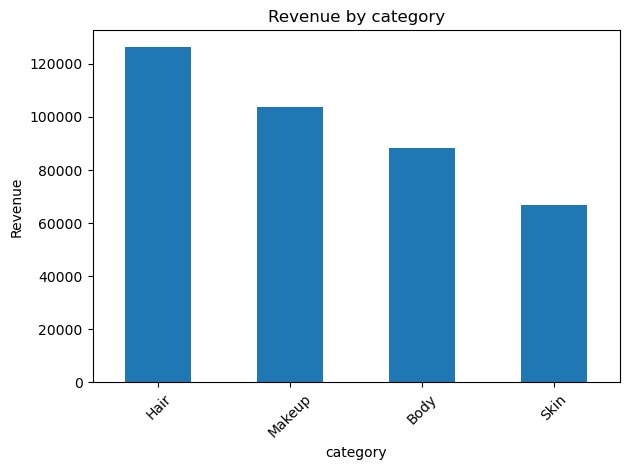

In [64]:
import matplotlib.pyplot as plt
category_Revenue.plot(kind="bar")
plt.title("Revenue by category")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
The category with the highest revenue is "Hair".
The category with the lowest revenue is "Skin".


# 2) Horizontal Bar chart- top 10 products

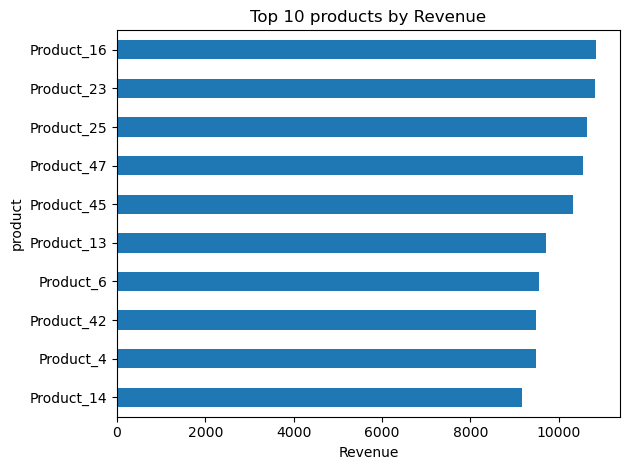

In [68]:
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("product")
plt.tight_layout()
plt.show()

# 3) Line chart- Monthly revenue

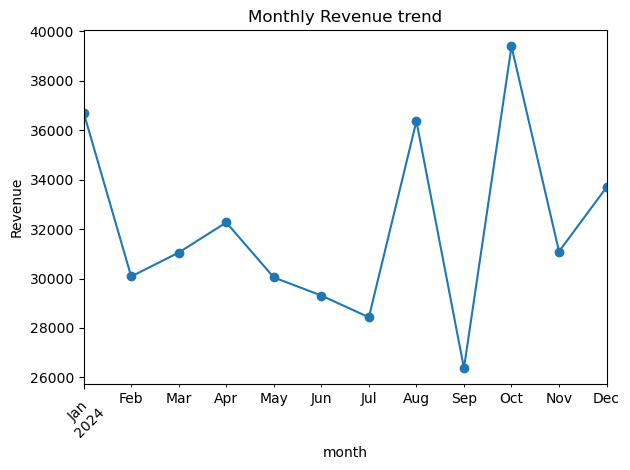

In [70]:
monthly_Revenue.plot(kind="line",marker="o")
plt.title("Monthly Revenue trend")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: 
1.Revenue decreased during "january to july" and then incresed during "july to october".
2.Highest_revenue was observed "october" month and lowest_revenue was observed in "september" month.

Bar chart- Revenue by country

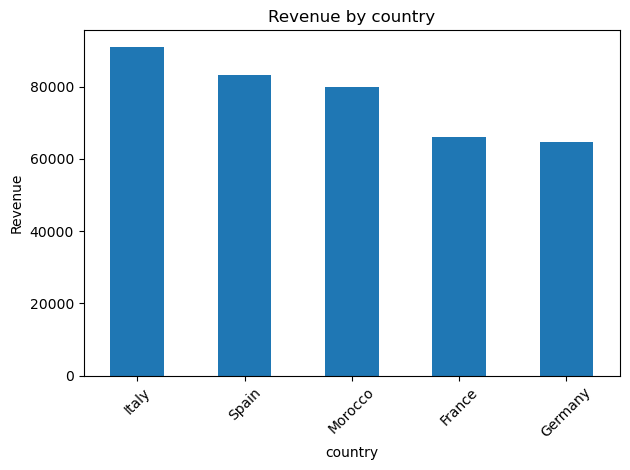

In [73]:
country_Revenue.plot(kind="bar")
plt.title("Revenue by country")
plt.xlabel("country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar chart- order status

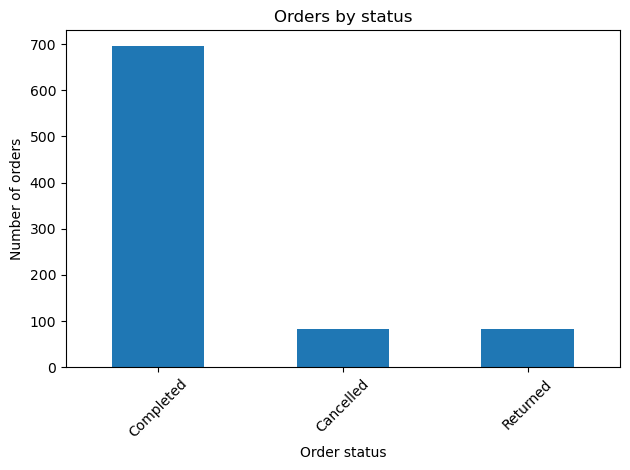

In [74]:
order_status.plot(kind="bar")
plt.title("Orders by status")
plt.xlabel("Order status")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()